# First Name: Elijah
# Last Name: Ang

# Import Libraries  

In [141]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import Data

In [143]:
bottle = pd.read_csv('bottle.csv', low_memory=True)

/var/folders/m_/5hjxnlm94j53h6kj050rk1300000gn/T/ipykernel_67186/162303065.py:1: DtypeWarning: Columns (47,61) have mixed types. Specify dtype option on import or set low_memory=False.
  bottle = pd.read_csv('bottle.csv', low_memory=True)


# Initial Data management

### Remove NaN for T_degC and find median

In [144]:
print(bottle.info())
print(bottle.head(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 895371 entries, 0 to 895370
Data columns (total 62 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Cst_Cnt              895371 non-null  int64  
 1   Btl_Cnt              895371 non-null  int64  
 2   Sta_ID               895371 non-null  object 
 3   Depth_ID             895371 non-null  object 
 4   Depthm               895371 non-null  int64  
 5   T_degC               884402 non-null  float64
 6   Salnty               848015 non-null  float64
 7   O2ml_L               725630 non-null  float64
 8   STheta               842675 non-null  float64
 9   O2Sat                690746 non-null  float64
 10  Oxy_µmol/Kg          690698 non-null  float64
 11  BtlNum               138967 non-null  float64
 12  RecInd               895371 non-null  int64  
 13  T_prec               884408 non-null  float64
 14  T_qual               24016 non-null   float64
 15  S_prec           

In [145]:
print(bottle['T_degC'].isna().sum())

10969


In [146]:
bottle_v2 = bottle.copy()

# Create a duplicate data set with rows where T_degC is not null
bottle_v2 = bottle_v2[bottle_v2['T_degC'].notna()]
print(bottle_v2['T_degC'].isna().sum())
print(bottle_v2['T_degC'].head(10))

0
0    10.50
1    10.46
2    10.46
3    10.45
4    10.45
5    10.45
6    10.45
7    10.24
8    10.06
9     9.86
Name: T_degC, dtype: float64


In [147]:
print(bottle_v2['T_degC'].median())

10.07


### Remove NaN for Salnty

In [148]:
print(bottle_v2['Salnty'].isna().sum())

39654


In [149]:
bottle_v2 = bottle_v2[bottle_v2['Salnty'].notna()]
print(bottle_v2['Salnty'].isna().sum())

0


### Create Depthm Categories

In [150]:
# convert to numeric
bottle_v2['Depthm'] = pd.to_numeric(bottle_v2['Depthm'], errors='coerce')

# drop missing depths
bottle_v2 = bottle_v2.dropna(subset=['Depthm'])

bins = [0, 100, 500, np.inf]
labels = ['Shallow', 'Mid', 'Deep']

bottle_v2['Depth_category'] = pd.cut(bottle_v2['Depthm'], bins=bins, labels=labels, include_lowest=True)

print(bottle_v2[['Depthm', 'Depth_category']].head(10))

   Depthm Depth_category
0       0        Shallow
1       8        Shallow
2      10        Shallow
3      19        Shallow
4      20        Shallow
5      30        Shallow
6      39        Shallow
7      50        Shallow
8      58        Shallow
9      75        Shallow


### Create O2ml_L Categories

In [151]:
print(bottle_v2['O2ml_L'].isna().sum())
print(bottle_v2['O2ml_L'].notna().sum())

153834
690914


In [152]:
bottle_v2 = bottle_v2.dropna(subset=['O2ml_L'])
bottle_v2['O2_category'] = pd.cut(bottle_v2['O2ml_L'], bins=5)
print(bottle_v2[['O2ml_L', 'O2_category']].head(10))

      O2ml_L      O2_category
2160    5.90  (-31.14, 11.13]
2161    6.02  (-31.14, 11.13]
2162    6.04  (-31.14, 11.13]
2163    6.06  (-31.14, 11.13]
2164    6.04  (-31.14, 11.13]
2165    6.01  (-31.14, 11.13]
2166    6.01  (-31.14, 11.13]
2167    5.78  (-31.14, 11.13]
2168    5.76  (-31.14, 11.13]
2169    5.60  (-31.14, 11.13]


### Task 5 data cleaning

In [153]:
task5 = bottle_v2[['Salnty','NO3uM','PO4uM','SiO3uM','Depth_category']].dropna()

# Task 1: Histogram

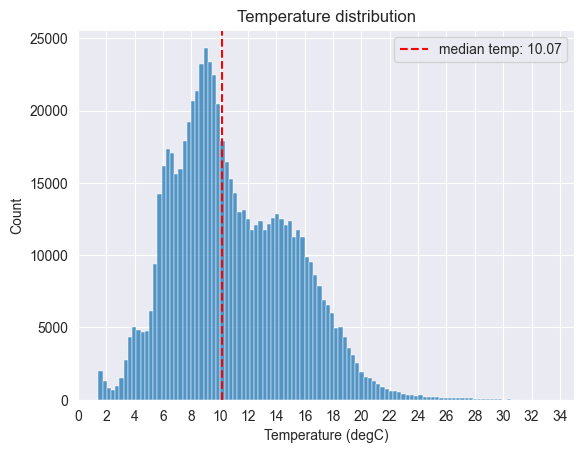

In [154]:
fig, ax = plt.subplots()

sns.histplot(x='T_degC', data=bottle_v2, ax=ax, bins=100)
ax.set_xlabel('Temperature (degC)')
ax.set_ylabel('Count')
ax.set_title('Temperature distribution')
ax.set_xlim(0, 35)
ax.set_xticks(np.arange(0, 35, 2))
ax.axvline(bottle_v2['T_degC'].median(), color='r', linestyle='--', label='median temp: 10.07')
ax.legend()
plt.show()

# Task 2: Boxplot

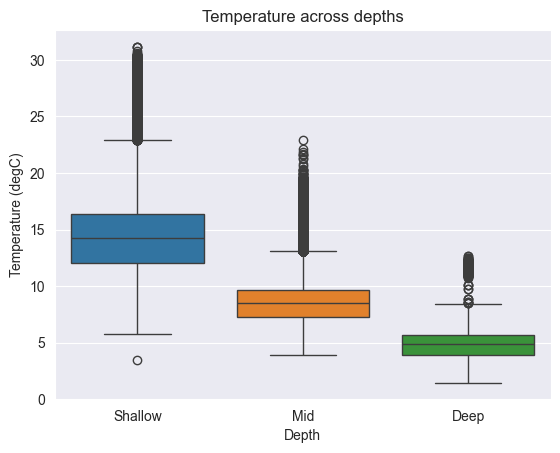

In [155]:
fig, ax = plt.subplots()

sns.boxplot(x='Depth_category', y='T_degC', data=bottle_v2, ax=ax, hue='Depth_category')
ax.set_xlabel('Depth')
ax.set_ylabel('Temperature (degC)')
ax.set_title('Temperature across depths')
plt.show()

# Task 3: Line chart 

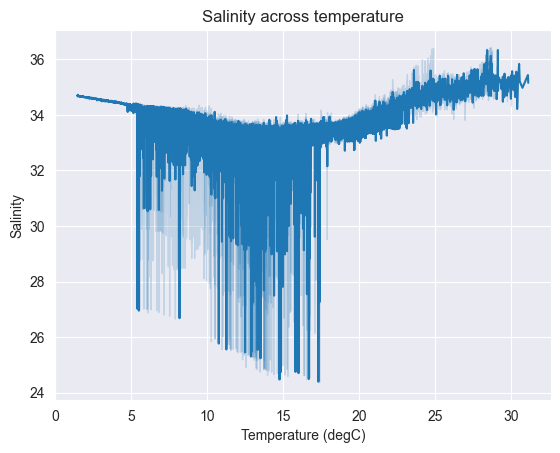

In [158]:
fig, ax = plt.subplots()

sns.lineplot(x='T_degC', y='Salnty', data=bottle_v2, ax=ax)
ax.set_xlabel('Temperature (degC)')
ax.set_ylabel('Salinity')
ax.set_title('Salinity across temperature')
plt.show()

# Task 4: Bubble chart 

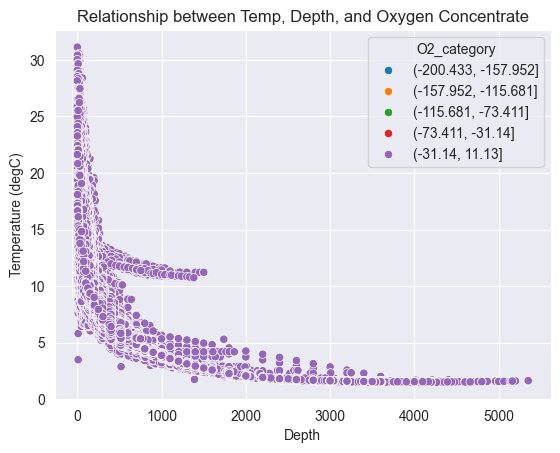

In [159]:
fig, ax = plt.subplots()

sns.scatterplot(x='Depthm', y='T_degC', hue='O2_category', data=bottle_v2, ax=ax)
ax.set_xlabel('Depth')
ax.set_ylabel('Temperature (degC)')
ax.set_title('Relationship between Temp, Depth, and Oxygen Concentrate')
plt.show()

# Task 5: Pairwise plot

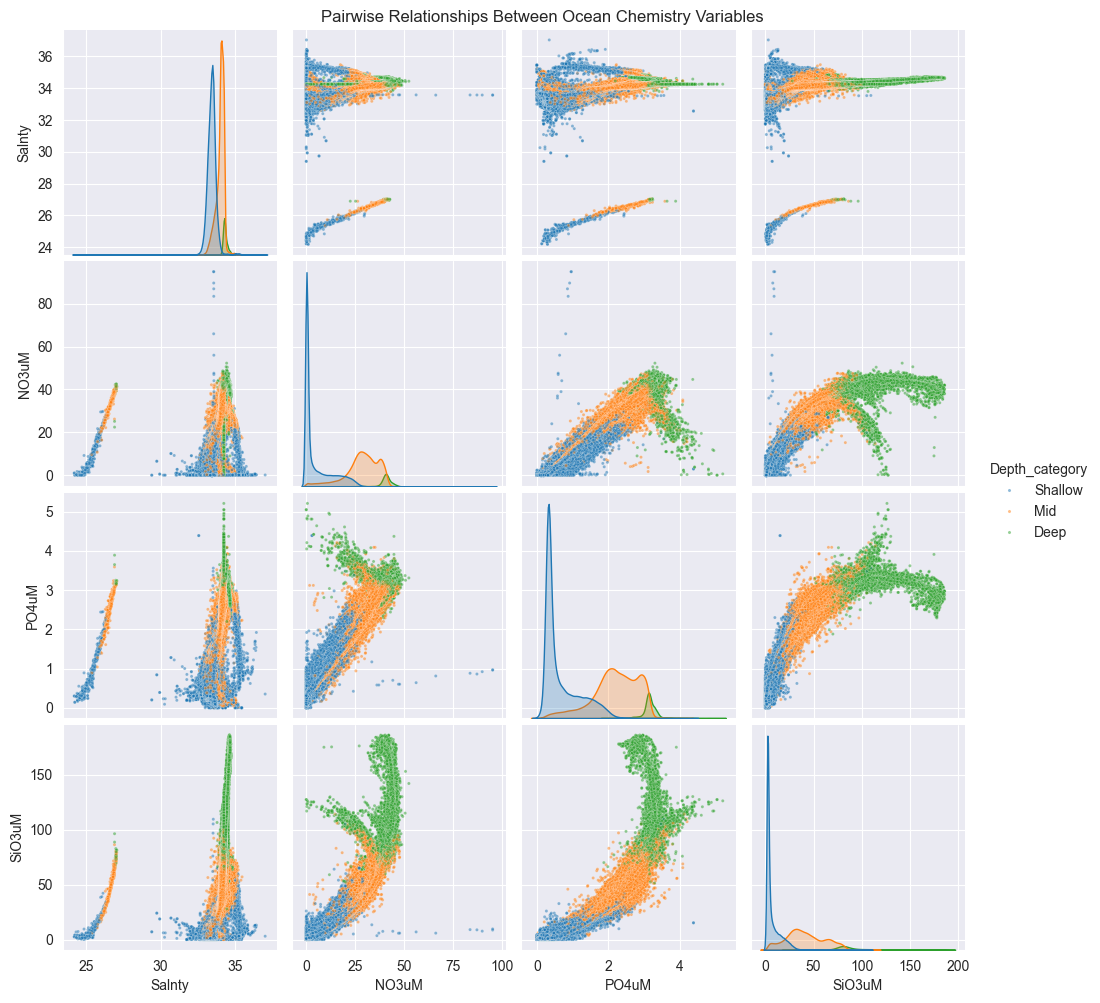

In [162]:
sns.pairplot(task5, hue='Depth_category', plot_kws=dict(s=5, alpha = 0.5))

plt.suptitle("Pairwise Relationships Between Ocean Chemistry Variables", y=1)

plt.show()